In [1]:
# Importa las librerías necesarias.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split

# Configura el formato general.
pd.options.display.float_format = '{:,.2f}'.format

# Define la ruta y carga el archivo. Asegura que el nombre del CSV coincida con el descargado.
ruta = os.path.join(r"C:\Users\patri\Downloads", "bank.csv") 
# Nota: El dataset bancario suele usar punto y coma como separador. Cambia a sep=',' si es necesario.
df = pd.read_csv(ruta, sep=';', encoding='latin1', dtype={'ITEM_CODE': str})

# 1. Muestra los datos.
print(df.head())
# 2. Muestra los nombres EXACTOS de las columnas (sin recortes).
print(df.columns.tolist())

   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent         1.10   
1   may         mon  ...         1    999         0  nonexistent         1.10   
2   may         mon  ...         1    999         0  nonexistent         1.10   
3   may         mon  ...         1    999         0  nonexistent         1.10   
4   may         mon  ...         1    999         0  nonexistent         1.10   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed

In [2]:
# Muestra los últimos registros del dataset.
print("--- Tail ---")
print(df.tail())

# Extrae una muestra aleatoria.
print("\n--- Sample ---")
print(df.sample(5))

# Muestra las dimensiones del dataset (filas, columnas).
print("\n--- Shape ---")
print(df.shape)

# Imprime la información técnica del dataset.
print("\n--- Info ---")
df.info()

--- Tail ---
       age          job  marital            education default housing loan  \
41183   73      retired  married  professional.course      no     yes   no   
41184   46  blue-collar  married  professional.course      no      no   no   
41185   56      retired  married    university.degree      no     yes   no   
41186   44   technician  married  professional.course      no      no   no   
41187   74      retired  married  professional.course      no     yes   no   

        contact month day_of_week  ...  campaign  pdays  previous  \
41183  cellular   nov         fri  ...         1    999         0   
41184  cellular   nov         fri  ...         1    999         0   
41185  cellular   nov         fri  ...         2    999         0   
41186  cellular   nov         fri  ...         1    999         0   
41187  cellular   nov         fri  ...         3    999         1   

          poutcome emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m  \
41183  nonexistent        

In [3]:
# Valida la existencia de nulos o información vacía.
print("--- Nulos ---")
print(df.isnull().sum())

# Muestra los tipos de datos de cada variable.
print("\n--- Tipos de Datos ---")
print(df.dtypes)

# Calcula estadísticas descriptivas de las variables numéricas.
print("\n--- Describe ---")
print(df.describe())

# Cuenta la cantidad de valores únicos por columna.
print("\n--- Nunique ---")
print(df.nunique())

--- Nulos ---
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

--- Tipos de Datos ---
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y        

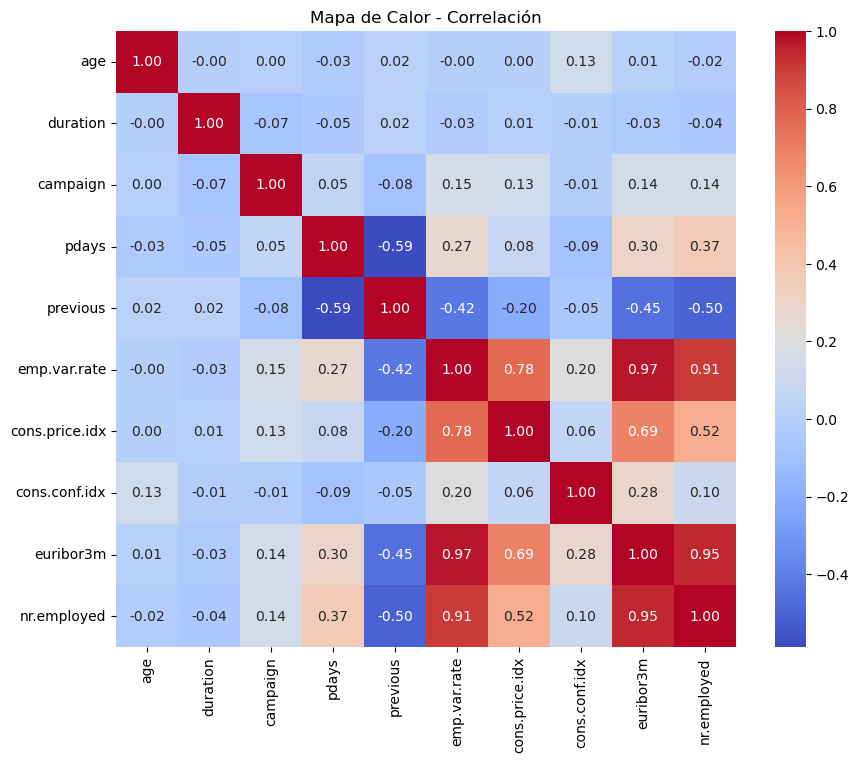

C:\Users\patri\AppData\Local\Temp\ipykernel_24124\2565400265.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['age'], bins=30, kde=True, color='blue')


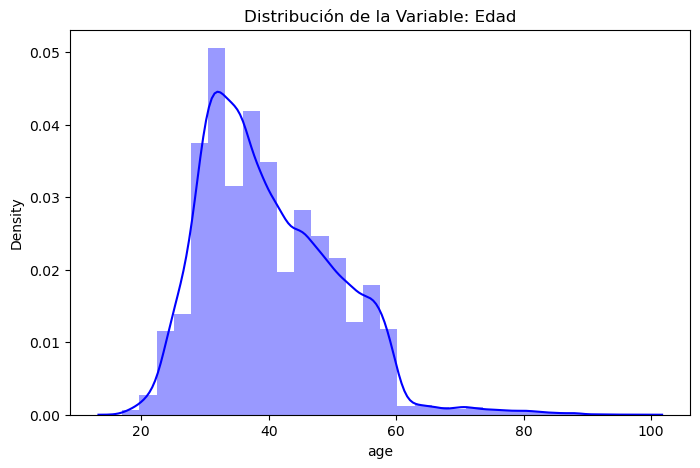

In [4]:
# Calcula la matriz de correlación solo para variables numéricas.
correlacion = df.select_dtypes(include=[np.number]).corr()

# Genera un mapa de calor para visualizar la correlación.
plt.figure(figsize=(10, 8))
sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor - Correlación')
plt.show()

# Visualiza la distribución de la edad usando sns.distplot.
plt.figure(figsize=(8, 5))
sns.distplot(df['age'], bins=30, kde=True, color='blue')
plt.title('Distribución de la Variable: Edad')
plt.show()

In [5]:
# Elimina variables que tengan alta correlación o no sean útiles para el modelo.
# Se usa 'duration' como ejemplo, ya que filtra información del futuro (se conoce tras la llamada).
columnas_a_eliminar = ['duration']
columnas_existentes = [col for col in columnas_a_eliminar if col in df.columns]

df = df.drop(columns=columnas_existentes)
print("Columnas eliminadas:", columnas_existentes)
print("Nueva dimensión del dataset:", df.shape)

Columnas eliminadas: ['duration']
Nueva dimensión del dataset: (41188, 20)


In [6]:
# Muestra el total de registros agrupados por estado civil.
print("--- Estado Civil ---")
print(df.groupby('marital').size())

# Muestra el total de registros agrupados por educación.
print("\n--- Educación ---")
print(df.groupby('education').size())

# Muestra el total de registros agrupados por trabajo.
print("\n--- Trabajo ---")
print(df.groupby('job').size())

--- Estado Civil ---
marital
divorced     4612
married     24928
single      11568
unknown        80
dtype: int64

--- Educación ---
education
basic.4y                4176
basic.6y                2292
basic.9y                6045
high.school             9515
illiterate                18
professional.course     5243
university.degree      12168
unknown                 1731
dtype: int64

--- Trabajo ---
job
admin.           10422
blue-collar       9254
entrepreneur      1456
housemaid         1060
management        2924
retired           1720
self-employed     1421
services          3969
student            875
technician        6743
unemployed        1014
unknown            330
dtype: int64


C:\Users\patri\AppData\Local\Temp\ipykernel_24124\1779658992.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='y', data=df, palette='Set2')


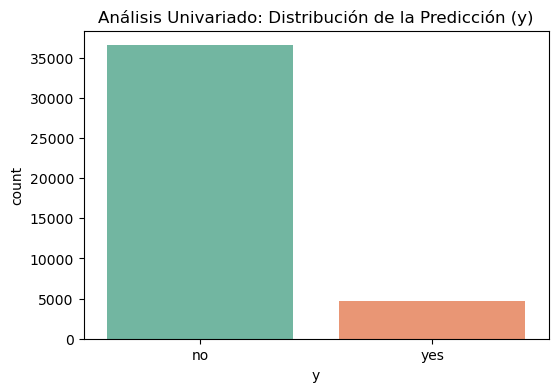

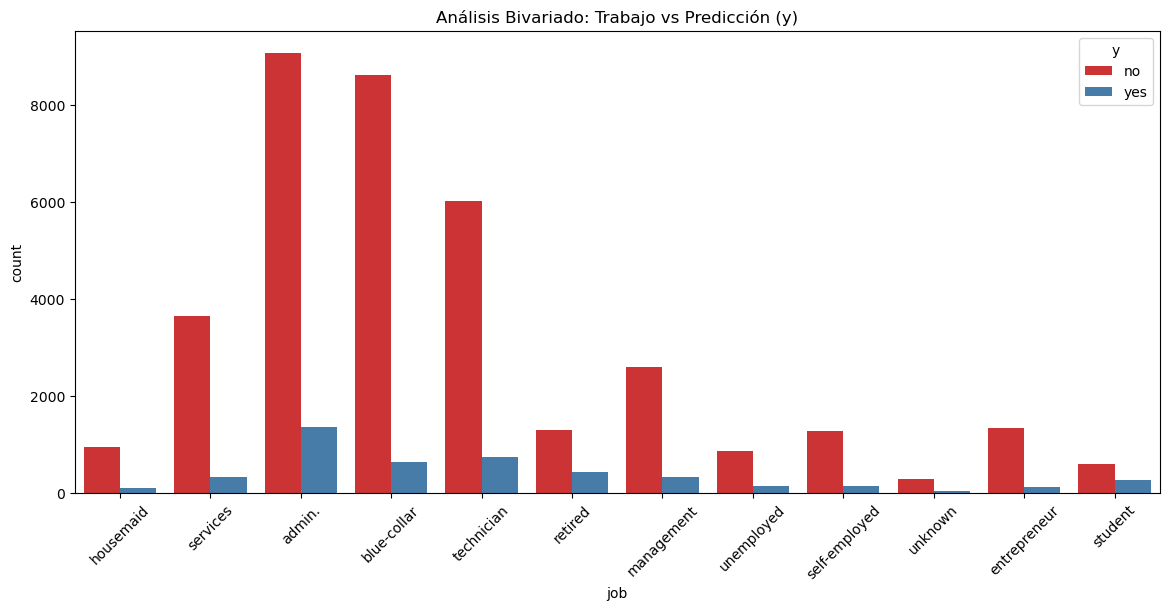

In [7]:
# Visualiza el análisis univariado de la variable objetivo 'y'.
plt.figure(figsize=(6, 4))
sns.countplot(x='y', data=df, palette='Set2')
plt.title('Análisis Univariado: Distribución de la Predicción (y)')
plt.show()

# Visualiza el análisis bivariado comparando el tipo de trabajo con la variable objetivo.
plt.figure(figsize=(14, 6))
sns.countplot(x='job', hue='y', data=df, palette='Set1')
plt.title('Análisis Bivariado: Trabajo vs Predicción (y)')
plt.xticks(rotation=45)
plt.show()

In [8]:
# Separa las variables predictoras (X) de la variable objetivo (y).
if 'y' in df.columns:
    X = df.drop(columns=['y'])
    y = df['y']
else:
    # Selecciona la última columna si la variable objetivo tiene otro nombre.
    X = df.iloc[:, :-1]
    y = df.iloc[:, -1]

# Transforma las variables categóricas en variables dummy para que el modelo pueda procesarlas.
X = pd.get_dummies(X, drop_first=True)

# Divide el dataset usando una proporción 70:30.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# Imprime las dimensiones resultantes para validar la división.
print("Dimensión de X_train:", X_train.shape)
print("Dimensión de X_test:", X_test.shape)
print("Dimensión de y_train:", y_train.shape)
print("Dimensión de y_test:", y_test.shape)

Dimensión de X_train: (28831, 52)
Dimensión de X_test: (12357, 52)
Dimensión de y_train: (28831,)
Dimensión de y_test: (12357,)
